### This code calibrates and evaluates the process-based models in sub-Saharan Africa (CIMMYT dataset). For sections 3.1, 3.2 and 3.4 of the paper.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy.optimize
import scipy.stats
from scipy.integrate import quad
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import copy
import calendar
from optimise_GDD_fctns import * #Phenology_set, run_GDD_and_get_RMSE, run_GDD_and_get_RMSE_derivs, plot_profiles_at_minimum, get_station_locations, put_ERA5_in_array

#import seaborn as sns

import plotting
import dataset_fctns
import modelling_fctns
import seaborn as sns
#from dwd_phenpy import Phenology_set

#import openeo
#import ee
## Trigger the authentication flow.
#ee.Authenticate()#(auth_mode='localhost')
# Initialize the library.
#ee.Initialize(project='ee-martinparker637')

c:\Users\wlwc1989\Documents\Phenology_Test_Notebooks\modelling_crop_phenology_in_data_scarce_regions_using_transfer_learning_code\process_based\parameter_calibration_model_evaluation\optimise_GDD_fctns.py:35: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  station_data = pd.read_csv("https://opendata.dwd.de/climate_environment/CDC/help/PH_Beschreibung_Phaenologie_Stationen_Jahresmelder.txt",sep = ";\s+|;\t+|;\s+\t+|;\t+\s+|;|\s+;|\t+;|\s+\t+;|\t+\s+;", encoding='cp1252', on_bad_lines='skip')


### First create some functions for calibration and evaluation

In [2]:
def train_test_by_year(ds, test_years):
    obs_for_testing = ds['year'].isin(test_years)
    train_ds = ds[~obs_for_testing]
    test_ds = ds[obs_for_testing]
    return train_ds, test_ds

In [3]:
def plot_from_comparison_array(comparison_array, title_extra='', method='scatter', savename = False, phase_list = ['beginning of flowering'], exclude_unfinished = False, growing_period_length = 300, col = 'blue'):
    if method == 'both':
        fig, axs = plt.subplots(len(phase_list), 2, figsize = (10, len(phase_list)*5))
    else:
        fig, axs = plt.subplots(1, len(phase_list), figsize = (len(phase_list)*5, 5))
    for phase_index, phase in enumerate(phase_list):
        number_unfinished = (comparison_array[f'modelled time to {phase}'] >= growing_period_length).sum()
        number_total = len(comparison_array)
        print(f'{number_unfinished} stations out of {number_total} did not reach the end of phase \'{phase}\'')
        if exclude_unfinished:
            comparison_array = comparison_array[comparison_array[f'modelled time to {phase}'] < growing_period_length].dropna()
        #comparison_array[f'observed time to {phase}'] = comparison_array[f'observed time to {phase}'].dt.days
        if len(phase_list) == 1:
            ax = axs
        else:
            ax = axs[phase_index]
        if method == 'regression':
            #x_estimator=np.mean,
            #minval = min(comparison_array[f'observed time to {phase}'].min(), comparison_array[f'modelled time to {phase}'].min()) - 1
            #maxval = max(comparison_array[f'observed time to {phase}'].max(), comparison_array[f'modelled time to {phase}'].max()) + 1
            minval = min(comparison_array[f'observed time to {phase}'].quantile(0.05), comparison_array[f'modelled time to {phase}'].quantile(0.05)) - 1
            maxval = max(comparison_array[f'observed time to {phase}'].quantile(0.95), comparison_array[f'modelled time to {phase}'].quantile(0.95)) + 1
            sns.regplot(x=f'modelled time to {phase}', y=f'observed time to {phase}', data=comparison_array, ax=axs,
                        scatter_kws={'alpha':0.5, 's':4},  x_bins=np.arange(minval - 5, maxval + 5, 2.5), color=col)
            axs.plot([minval, maxval], [minval, maxval], linestyle='--', color='k', lw=1, scalex=False, scaley=False)
            axs.set_xlim(minval, maxval)
            axs.set_ylim(minval, maxval)
            axs.set_title(f'Modelled and observed time to {phase}\n{title_extra}')
        elif method == 'errors':
            comparison_array['error'] = comparison_array[f'observed time to {phase}'] - comparison_array[f'modelled time to {phase}']
            sns.regplot(x=f'modelled time to {phase}', y='error', data=comparison_array, ax=axs,
                        scatter_kws={'alpha':0.5, 's':4},  x_bins=np.arange(30, 200, 5))
            axs.set_title(f'Comparison of fitted values and residuals {phase}\n{title_extra}')
        elif method == 'histogram':
            sns.histplot(x=f'modelled time to {phase}', data = comparison_array, ax=ax, label = 'modelled days to anthesis',
                        stat = 'density')
            sns.histplot(x=f'observed time to {phase}', data = comparison_array, ax=ax, label= 'observed days to anthesis',
                        stat = 'density')
            sns.set(font_scale=1.5)
            axs.set_title(f'Comparison of GDD modelled and observed time to\n{phase} {title_extra}')
            ax.set_xlabel('Days after planting')
            #ax.plot([minval, maxval], [minval, maxval], linestyle = '--', color='k')
            fig.legend(bbox_to_anchor = (1.2, 0.9))
            rsquared = r2_score(comparison_array[f'observed time to {phase}'], comparison_array[f'modelled time to {phase}'])
            print(f'R^2 value for model: {rsquared}')
            bias = comparison_array[f'observed time to {phase}'].mean() - comparison_array[f'modelled time to {phase}'].mean()
            variance_modelled = comparison_array[f'modelled time to {phase}'].var()
            print(f'Bias: {bias**2}\nVariance of modelled values: {variance_modelled}')
        elif method == 'both':
            ax = axs[0]
            minval = min(comparison_array[f'observed time to {phase}'].quantile(0.05), comparison_array[f'modelled time to {phase}'].quantile(0.05)) - 1
            maxval = max(comparison_array[f'observed time to {phase}'].quantile(0.95), comparison_array[f'modelled time to {phase}'].quantile(0.95)) + 1
            sns.regplot(x=f'modelled time to {phase}', y=f'observed time to {phase}', data=comparison_array, ax=ax,
                        scatter_kws={'alpha':0.5, 's':4},  x_bins=np.arange(minval - 5, maxval + 5, 5))
            ax.plot([minval, maxval], [minval, maxval], linestyle='--', color='k', lw=1, scalex=False, scaley=False)
            ax.set_xlim(minval, maxval)
            ax.set_ylim(minval, maxval)
            
            ax = axs[1]
            sns.histplot(x=f'modelled time to {phase}', data = comparison_array, ax=ax, label = 'modelled days to anthesis',
                        stat = 'density')
            sns.histplot(x=f'observed time to {phase}', data = comparison_array, ax=ax, label= 'observed days to anthesis',
                        stat = 'density')
            sns.set(font_scale=1.5)
            fig.suptitle(f'Comparison of GDD modelled and observed time to\n{phase} {title_extra}')
            ax.set_xlabel('Days after planting', fontsize = 18)
            ax.set_ylabel('Density', fontsize = 18)
            #ax.plot([minval, maxval], [minval, maxval], linestyle = '--', color='k')
            fig.legend(bbox_to_anchor = (1.2, 0.8))
            fig.tight_layout()
    rsquared = r2_score(comparison_array[f'observed time to {phase}'], comparison_array[f'modelled time to {phase}'])
    print(f'R^2 value for model: {rsquared}')
    bias = comparison_array[f'observed time to {phase}'].mean() - comparison_array[f'modelled time to {phase}'].mean()
    variance_modelled = comparison_array[f'modelled time to {phase}'].var()
    print(f'Bias: {bias**2} (sign {np.sign(bias)})\nVariance of modelled values: {variance_modelled}')
    if savename != False:
        fig.savefig(f'plots/{savename}', bbox_inches='tight')

In [ ]:
## (legacy, for some gradient based optimisers)
def run_GDD_and_get_RMSE_derivs(x, ds, driver_variable = 't2m', latlon_proj = True, response_type = 'Trapezoid', 
                                phase_list = ['beginning of flowering'],growing_period_length = 300,
                                thresholds = [100]):
    only_phase = phase_list[0]
    if response_type == 'Trapezoid':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Trapezoid_Temp_response(meantemp, x[1], x[2], x[3], x[4])
    elif response_type == 'Wang':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])

    ## Initiate development time storage object - a list with a value for all the stations, that will change over time and be stored in a list.
    t_dev = np.zeros(len(ds)) #Continuous development time. When this passes through some thresholds then have change in phase.
    accumulated_deriv_time_series = [[t_dev.copy()] for count in range(len(x))]
    dev_time_series = [t_dev.copy()]
    list_of_responses = [] 
    #Run model
    for day in range(growing_period_length):
        # Pull values for temperature out of data frame
        driver_values = ds[f'{driver_variable} at day {day}'].values
        resp = response(driver_values)
        # Calculate the response for each of these temperatures and add it to the total accumulated temperature
        if response_type == 'Trapezoid':
            response_deriv = x[0]*Trapezoid_Temp_derivs(driver_values, x[1], x[2], x[3], x[4])
            response_deriv[0, :] = response_deriv[0, :]/x[0]
        elif response_type == 'Wang':
            response_deriv_no_scale = Wang_Temp_Derivs(driver_values, x[1], x[2], x[3])
            response_deriv = [resp/x[0]] + [x[0]*deriv for deriv in response_deriv_no_scale]
        for x_index in range(len(x)):
            accumulated_deriv_time_series[x_index].append(accumulated_deriv_time_series[x_index][-1] + response_deriv[x_index])
        t_dev += resp#, t_dev)
        list_of_responses.append(resp)
        #print(len(accumulated_deriv_time_series[0][-1]))
        #print(accumulated_deriv_time_series[0][-1], t_dev/x[0])
        #Store the accumulated temperature in an array
        dev_time_series.append(t_dev.copy())

    # Add the year and station codes for indexing later and to check that extracting values didn't mix up indexes
    dev_time_series.append(ds['year'].values)
    dev_time_series.append(ds['Stations_id'].values)
    #print([p.shape for p in dev_time_series])
    model_dev_time_series = np.array(dev_time_series)
    #driver_array['Development Time'] = (('days from emergence', 'Emergence observation'), model_dev_time_series)
    column_names = np.concatenate([np.array([f'modelled time to {phase}' for phase in phase_list]), ['year'], ['Stations_id']])
    phase_dates_array = np.zeros((len(thresholds), model_dev_time_series.shape[1]))
    resps_list = np.zeros(model_dev_time_series.shape[1])
    for obs_index in range(model_dev_time_series.shape[1]):
        phase_dates_array[:, obs_index] = np.digitize(thresholds, model_dev_time_series[:-2, obs_index].astype(np.float64)) - 1
        resps_list[obs_index] = list_of_responses[int(phase_dates_array[-1, obs_index]) - 1][obs_index].mean()
    resps_list += 0.1*x[0]*(resps_list == 0)
    #print(phase_dates_array)
    phase_dates_array = np.concatenate([phase_dates_array, [model_dev_time_series[-2]], [model_dev_time_series[-1]]], axis=0)
    phase_dates_array = pd.DataFrame(phase_dates_array.T, columns = column_names)
    #phase_dates_array.iloc[:, :-1] = phase_dates_array.iloc[:, :-1].astype(int)
    #print(phase_dates_array.iloc[:, :-1])
    for x_index in range(len(x)):
        accumulated_derivs = accumulated_deriv_time_series[x_index]
        accumulated_derivs.append(ds['year'].values)
        accumulated_derivs.append(ds['Stations_id'].values)
        #print(accumulated_derivs[300])
        for phase in phase_list:
            accumulated_derivs.append(np.array(accumulated_derivs).T[np.arange(len(ds)), phase_dates_array[f'modelled time to {phase}'].values.astype(int)])
        column_names = np.array(['year', 'Stations_id'] + [f'x{x_index} deriv for {phase}'])
        #print(np.array(accumulated_derivs[301]))
        if x_index == 0:
            #derivs_array1 = pd.DataFrame(np.array(accumulated_derivs[301:]).T, columns = column_names)
            derivs_array = pd.DataFrame(np.array(accumulated_derivs[(growing_period_length + 1):]).T, columns = column_names)
            #print(derivs_array.shape)
        else:
            derivs_array2 = pd.DataFrame(np.array(accumulated_derivs[(growing_period_length + 1):]).T, columns = column_names)
            derivs_array = derivs_array.merge(derivs_array2, how='left', on=['year', 'Stations_id'])
            #print(derivs_array.shape)
    comparison_array = ds.merge(phase_dates_array, how='left', on=['year', 'Stations_id']).dropna(how='all')
    comparison_array = comparison_array.merge(derivs_array, on=['year', 'Stations_id'])
    def RMSE(residuals):
        return np.sqrt(np.mean(residuals**2))
    residuals = np.concatenate([(comparison_array[f'observed time to {phase}'] - comparison_array[f'modelled time to {phase}']).values for phase in phase_list])
    error = RMSE(residuals)
    #print(len(residuals), len(comparison_array))
    #print(residuals)
    deriv_list = [
        -((comparison_array[f'modelled time to {only_phase}'] - comparison_array[f'observed time to {only_phase}'])*
         comparison_array[f'x{xindex} deriv for {only_phase}']/resps_list).mean()/error for xindex in range(len(x))#x[0]
         #(comparison_array['modelled time to yellow ripeness']/(1 + comparison_array[f'x{xindex} deriv for yellow ripeness']) - comparison_array['modelled time to yellow ripeness'])).sum() for xindex in range(len(x))
    ]
    return deriv_list#, resps_list#, comparison_array#, comparison_array, derivs_array, accumulated_deriv_time_series#, resps_list#, comparison_array, phase_dates_array, derivs_array, derivs_array2, derivs_array1


In [5]:
def local_opt(x1s, train, test, error_fctn = run_GDD_and_get_RMSE, lower_bounds = [0.05, 4, 20, 20, 35], upper_bounds = [1, 12, 35, 35, 60], #ds
              great_threshold = 13, response_type = 'Trapezoid', phase_list = ['yellow ripeness'],
              method = 'trust-constr', modified_cost = False, thresholds = [100], growing_period_length = 185,
              maxiter = 50, split = True, CCNN_split = False, test_size = 0.5, random_state=1, itr = 0.5, bias_term = False):
    #if split:
    #    train, test = train_test_split(ds, test_size=test_size, random_state = random_state)
    #    #train_indices = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\model_output\\temp_CCNN_training.csv')
    #elif CCNN_split:
    #    test_indices = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\model_output\\compare_CCNN_results.csv')
    #    train_indices = train_indices.rename(columns = {'year': 'Referenzjahr'})
    #    test_indices = test_indices.rename(columns = {'year': 'Referenzjahr'})
    #    test = pd.merge(ds, test_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #    complement_indices = ds.index.difference(test.index)
    #
    #    # Filter df2 to keep only the rows with the complement indices
    #    train = ds.loc[complement_indices]
    #    #train = pd.merge(ds, train_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #    test = pd.merge(ds, test_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #else:
    #    train = ds
    #    test = ds
    only_phase = phase_list[0]
    if response_type == 'Trapezoid':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2],
                                                x[4] - x[3]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0, 0],
                                                [0, 0, -1, 1, 0],
                                                [0, 0, 0, -1, 1]])}
        constraints = scipy.optimize.LinearConstraint([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0], [0, 0, 0, -1, -1]], [0, 0, 0], [np.inf, np.inf, np.inf])
    elif response_type == 'Wang' or response_type == 'Convolved':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0],
                                                [0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        if bias_term:
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0]]),lb= [0, 0], ub=[1000, 1000])
        else:  
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0], [0, 0, -1, 1]]),lb= [0, 0], ub=[1000, 1000])
    elif response_type == 'Convolved_vary_spread':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0, 0, 0],
                                                [0, 0, -1, 1, 0, 0]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0, 0], [0, 0, -1, 1, 0, 0]]),lb= [0, 0], ub=[1000, 1000])
    elif response_type == 'Convolved':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0],
                                                [0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0, 0], [0, 0, -1, 1, 0, 0]]),lb= [0, 0], ub=[1000, 1000])
    elif response_type == 'Spline':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2],
                                                x[3]]),
                    'jac' : lambda x: np.array([[0 for count in range(20)],
                                                [0 for count in range(20)]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        constraints = scipy.optimize.LinearConstraint(np.array([[0 for count in range(20)], [0 for count in range(20)]]),lb= [-1, -1], ub=[1000, 1000])
    elif response_type == 'multi_phase':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2],
                                                x[6] - x[5],
                                                x[7] - x[6]]
                                                ),
                    'jac' : lambda x: np.array([[0, -1, 1, 0, 0, -1, 1, 0],
                                                [0, 0, -1, 1, 0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        if bias_term:
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0]]),lb= [0, 0], ub=[1000, 1000])
        else:  
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0], [0, 0, -1, 1]]),lb= [0, 0], ub=[1000, 1000])
    bounds = scipy.optimize.Bounds(lb=lower_bounds, ub = upper_bounds)
    x0 = np.array([1, 4, 25, 35, 45])
    final_mins = []
    for x0 in x1s:
        if method == 'trust-constr':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list, 
                                                                         new_unfinished_penalisation=modified_cost, 
                                                                         growing_period_length = growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'trust-constr',#'COBYQA',
                                    jac='3-point',#
                                    #jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', #jac='3-point',#[x0/1000 for x0 in 
                                    #                                            response_type = response_type, 
                                    #                                            phase_list = phase_list, 
                                    #                                            growing_period_length=growing_period_length,
                                    #                                            thresholds = thresholds),#
                                    constraints=[constraints],
                                    options={'verbose': 3, 'initial_tr_radius': itr, 'xtol':1e-7, 'maxiter':maxiter},# ,'gtol':1e-7, 'finite_diff_rel_step': 0.05
                                    bounds=bounds, tol=1e-9)
        elif method == 'SLSQP':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'SLSQP',
                                    #jac = '3-point',
                                    jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                                                                response_type = response_type, 
                                                                                phase_list = phase_list, 
                                                                                growing_period_length=growing_period_length,
                                                                                thresholds = thresholds),#jac='3-point',#
                                    constraints=[ineq_cons],
                                    options={'disp': 3, 'maxiter':maxiter, 'ftol': 1e-16},
                                    bounds=bounds)#, tol=1e-15)
        elif method == 'Nelder-Mead':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'Nelder-Mead',
                                    #jac = '3-point',
                                    #jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                    #                                            response_type = response_type, 
                                    #                                            phase_list = phase_list, 
                                    #                                            growing_period_length=growing_period_length,
                                    #                                            thresholds = thresholds),#jac='3-point',#
                                    options={'disp': True, 'fatol': 1e-10},#, 'maxiter':50
                                    bounds=bounds)#, tol=1e-15)
        elif method == 'Powell':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'Powell',
                                    #jac = '3-point',
                                    #jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                    #                                            response_type = response_type, 
                                    #                                            phase_list = phase_list, 
                                    #                                            growing_period_length=growing_period_length,
                                    #                                            thresholds = thresholds),#jac='3-point',#
                                    options={'disp': True},#, 'maxiter':50
                                    bounds=bounds)
        print(x0, res.x, x0 - res.x)
        RMSE = error_fctn(res.x, test, 't2m', response_type = response_type, phase_list = phase_list, growing_period_length = growing_period_length, thresholds = thresholds)
        #print('R^2: ', r2_score(c_array[f'observed time to {only_phase}'], c_array[f'modelled time to {only_phase}']))
        print('RMSE at opt on test set: ', RMSE)
        print('R^2:', 1 - (RMSE**2/(test[f'observed time to {only_phase}'].var()*((len(test) - 1)/len(test)))))
        final_mins.append(res.x)
    return final_mins, res, train, test

In [6]:
def run_GDD(x, ds, driver_variable, latlon_proj = True, response_type = 'Trapezoid', 
                             phase_list = ['beginning of flowering'], exclude_unfinished = False,
                             growing_period_length = 300, thresholds = [100], 
                             title_extra='', method='scatter', savename = False, plot=False, col='blue',
                             index_cols = ['lat', 'lon', 'Management', 'vargroup', 'Stations_id', 'year'],
                             step = 0.5): 
    #Change index_cols to ['year', 'Stations_id'] if using DE dataset
    len_index_cols = len(index_cols)
    if response_type == 'Trapezoid':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Trapezoid_Temp_response(meantemp, x[1], x[2], 0.2, 3)#x[3], x[4])
    elif response_type == 'Wang':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
    elif response_type == 'Convolved':
        #table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), 8, 3)#, x[4], x[5])#x[2]
        table2 = Convolved_Wang_Engel(np.arange(-10, 50, step), x[1], x[2], x[3], 3)
        table = scipy.ndimage.gaussian_filter(table2, 8/step, mode='constant', cval = 0, axes=0)
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/step, decimals = 1)).astype(int) + int(10/step)]*(meantemp > -10)
    elif response_type == 'Convolved_vary_spread':
        #table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), x[4], x[5])#, x[4], x[5])#x[2]
        table2 = Convolved_Wang_Engel(np.arange(-10, 50, step), x[1], x[2], x[3], x[5])
        table = scipy.ndimage.gaussian_filter(table2, x[4]*10/step, mode='constant', cval = 0, axes=0)
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/step, decimals = 1)).astype(int) + int(10/step)]*(meantemp > -10)
        #def response(meantemp):
        #    return x[0]*table[(np.just_spread':
        #table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), x[4], x[5])#, x[4], x[5])#x[2]
    elif response_type == 'Convolved_just_spread':
        table2 = Convolved_Wang_Engel(np.arange(-10, 50, step), 9.3, 28.3, 39.2, 3)
        table = scipy.ndimage.gaussian_filter(table2, x[1]*10/step, mode='constant', cval = 0, axes=0)
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/step, decimals = 1)).astype(int) + int(10/step)]*(meantemp > -10)
    elif response_type == 'multi_phase':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
        responses = [lambda meantemp: x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3]),
                     lambda meantemp: x[4]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[5], x[6], x[7])]
    driver_columns = [f'{driver_variable} at day {day}' for day in range(growing_period_length)]
    ds_for_model = ds[driver_columns + index_cols].copy()
    #ds_for_model.loc[:, driver_columns] = ds_for_model.loc[:, driver_columns]#.round(decimals = 10).astype(np.float64)
    if response_type == 'multi_phase':
        t_dev = np.zeros(len(ds_for_model))
        for i, colm in enumerate(driver_columns):
            resp = modelling_fctns.phase_dependent_response2(ds_for_model.loc[:, colm], t_dev, responses, thresholds)
            #resp2 = response(ds_for_model.loc[:, colm])
            #if np.any(resp != resp2):
            #    print(resp, resp2)
            #print(resp)
            t_dev += resp
            ds_for_model.loc[:, colm] = t_dev
    else:
        ds_for_model.loc[:, driver_columns] = response(ds_for_model[driver_columns]).cumsum(axis=1)
    model_dev_time_series = ds_for_model.values.T
    column_names = [np.array([f'modelled time to {phase}' for phase in phase_list]+ index_cols)]
    thresholds_for_phase = thresholds[-1:]
    #print(thresholds_for_phase, model_dev_time_series.shape[1])
    phase_dates_array = np.zeros((len(thresholds_for_phase), model_dev_time_series.shape[1]))#
    for obs_index in range(model_dev_time_series.shape[1]):
        #print(model_dev_time_series[:-2, obs_index])
        #print(model_dev_time_series[:-len_index_cols, obs_index])#.astype(np.float64))
        phase_dates_array[:, obs_index] = np.digitize(thresholds_for_phase, model_dev_time_series[:-len_index_cols, obs_index].astype(np.float64))    
    #print(phase_dates_array)
    phase_dates_array = np.concatenate([phase_dates_array, *[[model_dev_time_series[-(k + 1)]] for k in reversed(range(len_index_cols))]], axis=0)
    #print(column_names)
    phase_dates_array = pd.DataFrame(phase_dates_array.T, columns = column_names[0])
    #print(ds.columns.to_list(), phase_dates_array.columns.to_list())
    comparison_array = ds.T.drop_duplicates().T.merge(phase_dates_array, how='left', on=index_cols).dropna(how='all')
    #print(len(comparison_array), len(ds), len(phase_dates_array))
    if plot:
        plot_from_comparison_array(comparison_array, title_extra=title_extra, method=method, savename=savename, 
                                  phase_list=phase_list, exclude_unfinished=exclude_unfinished, growing_period_length=growing_period_length,
                                  col=col)
    return comparison_array

In [7]:
def run_GDD_and_get_RMSE(x, ds, driver_variable, latlon_proj = True, 
                         response_type = 'Trapezoid', phase_list = ['beginning of flowering'], 
                         new_unfinished_penalisation=False,
                         growing_period_length = 300, thresholds = [100]):
    comparison_array = run_GDD(x, ds, driver_variable, latlon_proj=latlon_proj,
                               response_type=response_type, phase_list=phase_list,
                               growing_period_length=growing_period_length, thresholds=thresholds)
    unfinished_penalty=0
    if new_unfinished_penalisation:
        unfinished_penalty = max((comparison_array[f'modelled time to {phase_list[0]}'] >growing_period_length - 3).sum() - 0.03*comparison_array.shape[0], 0)
        comparison_array = comparison_array.where(comparison_array[f'modelled time to {phase_list[0]}'] < growing_period_length).dropna()
    def RMSE(residuals):
        if len(residuals) == 0:
            return 0
        else:
            return np.sqrt(np.mean(residuals**2))
    phase = phase_list[0]
    residuals = (comparison_array[f'observed time to {phase}'] - comparison_array[f'modelled time to {phase}']).values # np.concatenate([(comparison_array[f'observed time to {phase}'].dt.days - comparison_array[f'modelled time to {phase}']).values for phase in phase_list])
    return RMSE(residuals) + unfinished_penalty#, comparison_array


In [8]:
def KFold_crossval(ds, k_folds, method = 'Nelder-Mead', index_cols = ['Stations_id', 'year', 'Management', 'vargroup'], 
                   just_scale = False, response_type = 'Wang', plot_profiles = False, plot_corrs = False, random_state = 1):
    #ds = ds.rename(columns = {'year': 'Referenzjahr'})
    kf = KFold(n_splits=k_folds, shuffle=True, random_state = random_state)
    loss_values = []
    R2s = []
    Biases = []
    Variances = []
    obsvars = []

    RMSEs = []
    SSEs = []
    STDs = []
    Corrs = []

    Mins = []
    LQs = []
    Medians = []
    UQs = []
    Maxs = []

    lengths = []

    params = []

    statyear = ds[index_cols].drop_duplicates()
    for fold, (train_idx, test_idx) in enumerate(kf.split(statyear)):
        train_statyear = statyear.iloc[train_idx]
        test_statyear = statyear.iloc[test_idx]
        train = ds.merge(train_statyear, on=index_cols, how = 'inner') #.loc[ds[['Stations_id', 'year']].isin(train_statyear)]
        test = ds.merge(test_statyear, on=index_cols, how = 'inner')
        lengths.append(len(test))
        if response_type == 'Convolved_vary_spread':
            x1s = [np.array([0.5, 9.3, 28.3, 39.2, 0.8, 3])]
            lb = [0.01, 7, 15, 38.5, 0, 0.1]
            ub = [5, 11, 31, 40, 1, 5]
        elif response_type == 'Convolved_just_spread':
            x1s = [np.array([0.5, 0.8])]
            lb = [0.01, 0]
            ub = [5, 2]
        else:
            x1s = [np.array([0.5, 8, 23, 39])]
            lb = [0.01, 7, 15, 38.5]
            ub = [5, 11, 31, 40]
        print(f'Fold {fold + 1}', len(test), len(train), len(ds))
        if just_scale:
            x_0 = scipy.optimize.minimize_scalar(lambda x: run_GDD_and_get_RMSE([x] + [9.3, 28.3, 39.2, 8, 3], train, 't2m', 
                                                                                response_type=response_type, phase_list = ['beginning of flowering'], 
                                                                                thresholds = [20], growing_period_length = 130),
                                                bounds = (0.01, 5),
                                                method='bounded',
                                                options = {'disp': 3})
            comparison_array = run_GDD([x_0.x, 9.3, 28.3, 39.2, 8, 3], test, 't2m', response_type=response_type, phase_list = ['beginning of flowering'], exclude_unfinished=False, growing_period_length=160, 
                                            thresholds = [20], title_extra='Full set', method = 'regression')
            params.append(x_0.x)
        else:
            fm = local_opt(x1s, train, test, error_fctn = run_GDD_and_get_RMSE,
                        lower_bounds = lb, upper_bounds = ub,
                        great_threshold = 13, response_type = response_type,
                        phase_list = ['beginning of flowering'],
                        method=method,
                        thresholds = [20], growing_period_length=130,
                        test_size = 0.02, maxiter=200)
            params.append(fm[0][0])
            #print('Parameters: ', fm)
            if plot_profiles:
                plot_profiles_at_minimum(fm[0][0], train, 
                                    lb=[0.01, 7, 20, 38.5], ub = [5, 11, 31, 40], 
                                    response_type = response_type, phase_list = ['beginning of flowering'],
                                    growing_period_length = 180, thresholds = [20])
            #print(fm[0][0])
            comparison_array = run_GDD(fm[0][0], test, 't2m', response_type=response_type, phase_list = ['beginning of flowering'], exclude_unfinished=False, growing_period_length=130, 
                                            thresholds = [20], title_extra='Full set', method = 'regression')
        #RMSE = run_GDD_and_get_RMSE(fm[0][0], test, 't2m', response_type='Wang', phase_list = ['beginning of flowering'], growing_period_length=130, thresholds = [20])
        #print(1 - (RMSE**2/(test[f'observed time to beginning of flowering'].var()*((len(test) - 1)/len(test)))))
        comparison_array['Error'] = comparison_array['observed time to beginning of flowering'] - comparison_array['modelled time to beginning of flowering']
        #print(len(comparison_array))
        r2_score_model = r2_score(comparison_array['observed time to beginning of flowering'], comparison_array['modelled time to beginning of flowering'])
        bias_model = 0#(comparison_array['Error']).mean()
        variance = comparison_array['modelled time to beginning of flowering'].var()
        variance_observed = comparison_array['observed time to beginning of flowering'].var()

        RMSE = np.sqrt(np.mean((comparison_array['Error'] - bias_model)**2))
        SSE = np.sum((comparison_array['Error'] - bias_model)**2)
        #print(1 - )
        STD = comparison_array['modelled time to beginning of flowering'].std() 
        Corr = comparison_array['observed time to beginning of flowering'].corr(comparison_array['modelled time to beginning of flowering'])

        RMSEs.append(RMSE)
        SSEs.append(SSE)
        STDs.append(STD)
        Corrs.append(Corr)
        
        Mins.append(comparison_array['Error'].min())
        LQs.append(comparison_array['Error'].quantile(0.25))
        Medians.append(comparison_array['Error'].median())
        UQs.append(comparison_array['Error'].quantile(0.75))
        Maxs.append(comparison_array['Error'].max())

        R2s.append(r2_score_model)
        Biases.append(bias_model)
        Variances.append(variance)
        obsvars.append(variance_observed)
        if fold == 0:
            cfs = comparison_array
        else:
            cfs = pd.concat((cfs, comparison_array))

        print(f'Fold: {fold + 1}\nR2: {r2_score_model}\nBias: {bias_model}\nVariance: {variance}')
        #print(comparison_array[['observed time to beginning of flowering', 'modelled time to beginning of flowering']])
        comparison_array['modelled time to beginning of flowering'] = comparison_array['modelled time to beginning of flowering'].astype(float)
        comparison_array['observed time to beginning of flowering'] = comparison_array['observed time to beginning of flowering'].astype(float)
        comparison_frame = comparison_array
        if plot_corrs:
            fig, ax=plt.subplots()
            sns.regplot(x='modelled time to beginning of flowering', y='observed time to beginning of flowering', data = comparison_array,
                        scatter_kws={'alpha':0.5, 's':4},  x_bins=10)
            maxval = max(comparison_frame['modelled time to beginning of flowering'].max(), comparison_frame['observed time to beginning of flowering'].max())
            minval = min(comparison_frame['modelled time to beginning of flowering'].min(), comparison_frame['observed time to beginning of flowering'].min())
            ax.plot([minval, maxval], [minval, maxval], linestyle = '--', color='k')
    print(f'Average score: {np.mean(R2s)}')
    return cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params

In [10]:
def make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, model, region, eval_method):
    error_df = pd.DataFrame({
        'model': [model],
        'region': [region],
        'evaluation method': [eval_method],
        'R2': [np.mean(R2s)],
        'Bias (obs minus modelled)': [np.mean(Biases)],
        'Variance': [np.mean(Variances)],
        'RMSE': [np.mean(RMSEs)],
        'STD': [np.mean(STDs)],
        'Corr': [np.mean(Corrs)],
        'Min': [np.mean(Mins)],
        'LQ': [np.mean(LQs)],
        'Median': [np.mean(Medians)],
        'UQ': [np.mean(UQs)],
        'Max': [np.mean(Maxs)]
    })
    return error_df

In [ ]:
def cols_in_other(df1, df2, compare_cols):
    index1 = pd.MultiIndex.from_arrays([df1[col] for col in compare_cols])
    index2 = pd.MultiIndex.from_arrays([df2[col] for col in compare_cols])
    return index1.isin(index2)

In [ ]:
def split_ds_by_AEZ5(ds):
    ds_semiarid_low = ds.loc[ds['AEZ'].isin([1])].groupby(['Stations_id', 'year']).head(2)
    ds_arid_low = ds.loc[ds['AEZ'].isin([26, 29])].groupby(['Stations_id', 'year']).head(2)
    ds_subhumid_low = ds.loc[ds['AEZ'].isin([2])].groupby(['Stations_id', 'year']).head(2)
    ds_humid_low = ds.loc[ds['AEZ'].isin([3])].groupby(['Stations_id', 'year']).head(2)
    ds_arid_high = ds.loc[ds['AEZ'].isin([4])].groupby(['Stations_id', 'year']).head(2)
    ds_humid_high = ds.loc[ds['AEZ'].isin([5])].groupby(['Stations_id', 'year']).head(2)
    ds_cool = ds.loc[ds['AEZ'].isin([10, 11, 14])].groupby(['Stations_id', 'year']).head(2)
    print(#f'\nnum cool: {len(ds_cool)}',
        f'\nnum semiarid low: {len(ds_semiarid_low)}',
        f'\nnum arid high: {len(ds_arid_high)}',
        f'\nnum humid low: {len(ds_humid_low)}',
        f'\nnum subhumid low: {len(ds_subhumid_low)}',
        f'\nnum subhumid high: {len(ds_humid_high)}')
    ds_dict = {#'cool': ds_cool,
               'semiarid low': ds_semiarid_low,
               'arid high': ds_arid_high,
               'humid low': ds_humid_low,
               'subhumid low': ds_subhumid_low,
               'humid high': ds_humid_high}
    return ds_dict

In [ ]:
def k_fold_crossval_regions(ds_dict, index_cols = ['Stations_id', 'year', 'Management', 'vargroup'], 
                            response_type = 'Wang', plot_profiles=False, just_scale = False,
                            method='Nelder-Mead', plot_corrs = False, random_state = 1):
    SSE_all_reg = []
    length_all_reg = []
    obsvars_all_reg = []
    comparison_frames = []
    for region in ds_dict.keys():
        #get data for specific region
        ds = ds_dict[region]
        if len(ds) < 10:
            continue
        #convert to pytorch format
        cf, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params = KFold_crossval(ds, 5, 
                                                                                                                               method = method,
                                                                                                                               index_cols = index_cols,
                                                                                                                               response_type = response_type,
                                                                                                                               just_scale=just_scale,
                                                                                                                               plot_profiles=plot_profiles,
                                                                                                                               plot_corrs=plot_corrs,
                                                                                                                               random_state=random_state)
        print(region, R2s)
        #Store sum of squared errors, variance of obs and length of folds for evaluation
        print(1 - (np.array(SSEs)/((np.array(lengths) - 1)*np.array(obsvars))))
        SSE_all_reg.append(SSEs)
        length_all_reg.append(lengths)
        obsvars_all_reg.append(obsvars)
        comparison_frames.append(cf)
    results_dict = {'SSEs': SSE_all_reg,
                    'observed variances': obsvars_all_reg,
                    'fold lengths': length_all_reg,
                    'comparison_frames': comparison_frames}
    return results_dict

In [ ]:
def skill_score_all_reg(score_dict):
    SSE_all_reg = np.array(score_dict['SSEs'])
    obsvars_all_reg = np.nan_to_num(np.array(score_dict['observed variances']))
    length_all_reg = np.array(score_dict['fold lengths'])
    MSE_all_reg = SSE_all_reg.sum(axis=0)/length_all_reg.sum(axis = 0)
    R2_all_reg = 1 - (SSE_all_reg.sum(axis=0)/((length_all_reg - 1)*obsvars_all_reg).sum(axis=0))
    R2_all_reg_split = 1 - (SSE_all_reg/((length_all_reg - 1)*obsvars_all_reg))
    #R2_pooled = 1 - (SSE_all_reg.sum(axis=1)/((length_all_reg - 1)*obsvars_all_reg).sum(axis=1))
    R2_pooled = []
    for cf in score_dict['comparison_frames']:
        R2_pooled.append(r2_score(cf['observed time to beginning of flowering'], cf['modelled time to beginning of flowering']))
    R2_pooled = np.array(R2_pooled)
    #print(R2_all_reg, ((length_all_reg - 1)*obsvars_all_reg).sum(axis=0))
    return R2_all_reg, R2_all_reg_split, R2_pooled

def make_df_from_score_dict(score_dict, TL_method = 'NA', variety = 'NA'):
    R2s, R2s_split, R2s_pooled = skill_score_all_reg(score_dict)
    df = pd.DataFrame()
    df['R2 score'] = R2s_split.mean(axis=1)
    df_pooled = pd.DataFrame()
    df_pooled['R2 score'] = R2s_pooled
    df['Variety'] = variety
    df_pooled['Variety'] = variety
    df_full_model = pd.DataFrame()
    df_full_model['Variety'] = [variety]
    df_full_model['R2 score'] = [R2s.mean()]
    return df, df_pooled, df_full_model

### Now read in the datasets

In [ ]:
ds_inputs_SSA = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\SSA_ML_ERA5_1999_2008_with_varieties_fixed_vpd.csv')
ds_inputs_SSA=ds_inputs_SSA.rename(columns={'Referenzjahr':'year'})
ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['observed time to beginning of flowering'] < 105]
ds_sites_AEZ2 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\African_data\\Lobell2011\\EIL_site_latlon_with_AEZ_filled.csv')
ds_inputs_SSA = ds_inputs_SSA.merge(ds_sites_AEZ2.rename(columns = {'LocationID': 'Stations_id'})[['Stations_id', 'AEZ2']], on='Stations_id', how='left')
ds_inputs_SSA['AEZ'] = ds_inputs_SSA['AEZ2']
ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['lat'] > -25]

In [ ]:
#ds_SSA_early = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'EPOP')|(ds_inputs_SSA['vargroup'] == 'EIHY')].groupby(['Stations_id', 'year', 'Management']).first().reset_index().drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
#ds_SSA_early = ds_SSA_early.loc[(ds_SSA_early['Management'] == 'Optimal')|(ds_SSA_early['Management'] == 'Low pH')|(ds_SSA_early['Management'] == 'Low N')].groupby(['Stations_id', 'year']).first().reset_index()
#early_ds_dict = split_ds_by_AEZ2(ds_SSA_early)
ds_SSA_early = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'EPOP')|(ds_inputs_SSA['vargroup'] == 'EIHY')].groupby(['Stations_id', 'year', 'Management']).first().reset_index().drop(columns=['Unnamed: 0'])#, 'Unnamed: 0.1'])
ds_SSA_early = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'EPOP')|(ds_inputs_SSA['vargroup'] == 'EIHY')].reset_index().drop(columns=['Unnamed: 0'])#, 'Unnamed: 0.1'])
#ds_SSA_early.loc[:,'Stations_id'] = ds_SSA_early['Stations_id'].astype(str) + ds_SSA_early['Management'].astype(str) + ds_SSA_early['vargroup'].astype(str)
early_ds_dict = split_ds_by_AEZ5(ds_SSA_early)


num semiarid low: 120 
num arid high: 59 
num humid low: 26 
num subhumid low: 67 
num subhumid high: 45


In [ ]:
#ds_SSA_early[['Stations_id', 'year']].drop_duplicates()

In [ ]:
#ds_SSA_late = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'ILPO')|(ds_inputs_SSA['vargroup'] == 'ILHY')].groupby(['Stations_id', 'year', 'Management']).first().reset_index().drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
#ds_SSA_late = ds_SSA_late.loc[(ds_SSA_late['Management'] == 'Optimal')|(ds_SSA_late['Management'] == 'Low pH')|(ds_SSA_late['Management'] == 'Low N')].groupby(['Stations_id', 'year']).first().reset_index()
#late_ds_dict = split_ds_by_AEZ2(ds_SSA_late)
ds_SSA_late = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'ILPO')|(ds_inputs_SSA['vargroup'] == 'ILHY')].reset_index().drop(columns=['Unnamed: 0'])#, 'Unnamed: 0.1'])
#ds_SSA_late.loc[:,'Stations_id'] = ds_SSA_late['Stations_id'].astype(str) + ds_SSA_late['Management'].astype(str) + ds_SSA_late['vargroup'].astype(str)
late_ds_dict = split_ds_by_AEZ5(ds_SSA_late)


num semiarid low: 101 
num arid high: 50 
num humid low: 17 
num subhumid low: 68 
num subhumid high: 46


### Section 3.1: Run the calibration on the whole CIMMYT dataset with the Wang-Engel response function.

In [106]:
cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params = KFold_crossval(ds_inputs_SSA, 5, index_cols = ['Stations_id', 'year'])

Fold 1 123 540 663
Optimization terminated successfully.
         Current function value: 8.678411
         Iterations: 63
         Function evaluations: 150
[ 0.5  8.  28.  39. ] [ 0.31645072  7.05043925 24.55601052 39.32086971] [ 0.18354928  0.94956075  3.44398948 -0.32086971]
RMSE at opt on test set:  10.565706144951383
R^2: 0.31835342188872306
Fold: 1
R2: 0.3183534218887224
Bias: 0
Variance: 64.6054911368786
Fold 2 137 526 663
Optimization terminated successfully.
         Current function value: 9.077926
         Iterations: 65
         Function evaluations: 158
[ 0.5  8.  28.  39. ] [ 0.31426228  7.16370297 24.40623489 39.30390911] [ 0.18573772  0.83629703  3.59376511 -0.30390911]
RMSE at opt on test set:  9.048127604023174
R^2: 0.30870276043452183
Fold: 2
R2: 0.3087027604345217
Bias: 0
Variance: 14.80785744954916
Fold 3 126 537 663
Optimization terminated successfully.
         Current function value: 9.035312
         Iterations: 73
         Function evaluations: 158
[ 0.5  8. 

In [113]:
cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params = KFold_crossval(ds_inputs_SSA, 5, index_cols = ['Stations_id', 'year'], just_scale = True)

Fold 1 123 540 663
 
 Func-count     x          f(x)          Procedure
    1        1.91601       54.911        initial
    2        3.09399      60.8135        golden
    3        1.18798      45.5828        golden
    4       0.738031      31.3589        golden
    5       0.459948      15.7688        golden
    6       0.288083      31.3865        golden
    7       0.513151      18.8193        parabolic
    8       0.394301      14.9293        golden
    9       0.410067      14.4462        parabolic
   10       0.419781      14.4158        parabolic
   11        0.41637      14.4151        parabolic
   12        0.41788      14.3942        parabolic
   13       0.418062      14.4057        parabolic
   14       0.417277      14.3955        parabolic
   15        0.41765      14.3881        golden
   16       0.417592      14.4046        parabolic
   17       0.417737       14.393        golden
   18       0.417683      14.3897        golden
   19       0.417628      14.3881      

### Section 3.2: Run the calibration on the whole CIMMYT dataset using the Wang-Engel response function and incorporating subgrid-scale averaging.

In [118]:
cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params = KFold_crossval(ds_inputs_SSA, 5, index_cols = ['Stations_id', 'year'], response_type = 'Convolved')

Fold 1 123 540 663
Optimization terminated successfully.
         Current function value: 8.463320
         Iterations: 52
         Function evaluations: 133
[ 0.5  8.  28.  39. ] [ 0.46926925  9.03877877 26.95021292 39.21014219] [ 0.03073075 -1.03877877  1.04978708 -0.21014219]
RMSE at opt on test set:  9.966610925150702
R^2: 0.3934631205765362
Fold: 1
R2: 0.39346312057653565
Bias: 0
Variance: 92.70771691323468
Fold 2 137 526 663
Optimization terminated successfully.
         Current function value: 8.703502
         Iterations: 58
         Function evaluations: 135
[ 0.5  8.  28.  39. ] [ 0.44153149  7.93604348 26.32738382 39.31324157] [ 0.05846851  0.06395652  1.67261618 -0.31324157]
RMSE at opt on test set:  8.590862570663623
R^2: 0.37680934475333916
Fold: 2
R2: 0.3768093447533388
Bias: 0
Variance: 23.082975525976817
Fold 3 126 537 663
Optimization terminated successfully.
         Current function value: 8.680658
         Iterations: 77
         Function evaluations: 169
[ 0.5  8.

In [119]:
err_df = make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD Wang response', 'SSA', '5-fold CV')
err_df.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\important_results\\NEW_error_df_TREx_SSA.csv')

### Legacy code with same purpose

In [131]:
cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params = KFold_crossval(ds_inputs_SSA, 5, index_cols = ['Stations_id', 'year'], response_type = 'Convolved', just_scale = True)

Fold 1 123 540 663
 
 Func-count     x          f(x)          Procedure
    1        1.91601      52.0239        initial
    2        3.09399      59.0203        golden
    3        1.18798      40.7147        golden
    4       0.738031      23.0073        golden
    5       0.459948      12.4394        golden
    6       0.288083      51.1529        golden
    7       0.566166      11.0375        golden
    8       0.535209      9.41079        parabolic
    9       0.520612      9.08203        parabolic
   10       0.510824      9.03881        parabolic
   11       0.512744      9.07755        parabolic
   12       0.491391      9.70691        golden
   13       0.503401      9.21261        golden
   14       0.507988      9.11277        golden
   15       0.509741      9.04833        golden
   16       0.510738       9.0429        parabolic
   17       0.511557      9.04393        golden
   18       0.511138      9.01593        parabolic
   19       0.511298      9.02558        gold

In [132]:
err_df = make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD TREx response', 'SSA', '5-fold CV')
err_df.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\important_results\\NEW_error_df_TREx_Sanchez_SSA.csv')

In [120]:
np.array(params).mean(axis=0)

array([ 0.45762509,  8.08630901, 26.79581137, 39.1728868 ])

In [104]:
np.array(params).mean(axis=0)

array([ 0.3165638 ,  8.42068571, 24.36840505, 39.09078988])

In [ ]:
cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params = KFold_crossval(ds_inputs_SSA, 5, index_cols = ['Stations_id', 'year'])

In [ ]:
cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params = KFold_crossval(ds_inputs_SSA, 5, index_cols = ['Stations_id', 'year'], response_type = 'Convolved')

In [ ]:
err_df = make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD Wang response', 'SSA', '5-fold CV')
err_df.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\important_results\\NEW_error_df_GDD_SSA.csv')

In [114]:
err_df = make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD Wang response', 'SSA', '5-fold CV')
err_df.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\important_results\\NEW_error_df_GDD_SSA_Sanchez.csv')

### Section 3.4 (baseline): split just by variety group (not AEZ)

In [ ]:
no_regions_tests_dict = {'early full': ds_SSA_early,
                   'late full': ds_SSA_late}
results_dict_no_region = k_fold_crossval_regions(no_regions_tests_dict, index_cols=['Stations_id', 'year'])
df_noreg, df_noreg_pooled, ___ = make_df_from_score_dict(results_dict_no_region)
df_noreg_pooled['Variety'] = ['Early', 'Late']
df_noreg_pooled['Model'] = 'GDD'
df_noreg_pooled.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_regions_pooled_score_GDD.csv')

In [ ]:
for ind, score_dict in enumerate([results_dict_combined]):# results_dict_late]):
    variety = ['combined'][ind]
    TL_method = ['first', 'first'][ind]
    df_novar, df_novar_pooled, ___ = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    if ind == 1:
        df_novar['region'] = np.array(['arid low', 'arid high', 'humid low', 'humid high'])
        df_novar_pooled['region'] = np.array(['arid low', 'arid high', 'humid low', 'humid high'])
    else:
        df_novar['region'] = np.array(['arid low', 'arid high', 'humid low', 'humid high'])
        df_novar_pooled['region'] = np.array(['arid low', 'arid high', 'humid low', 'humid high'])
#df_pooled = df_pooled.drop(4)

In [ ]:
df_pooled.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_varieties_score_GDD_trust_constr.csv')

### Section 3.4 (baseline): Now split by AEZ and calibrate

In [22]:
combined_variety_tests_dict = {key: pd.concat((early_ds_dict[key], late_ds_dict[key])) for key in early_ds_dict.keys()}
results_dict_combined = k_fold_crossval_regions(combined_variety_tests_dict, index_cols=['Stations_id', 'year'])

Fold 1 38 183 221
Optimization terminated successfully.
         Current function value: 8.416416
         Iterations: 63
         Function evaluations: 149
[ 0.5  8.  28.  39. ] [ 0.33857994  9.75364941 26.27853862 39.1917185 ] [ 0.16142006 -1.75364941  1.72146138 -0.1917185 ]
RMSE at opt on test set:  11.361291624125359
R^2: 0.5436985898942421
Fold: 1
R2: 0.5436985898942421
Bias: 0
Variance: 102.0633001422475
Fold 2 46 175 221
Optimization terminated successfully.
         Current function value: 9.327073
         Iterations: 58
         Function evaluations: 136
[ 0.5  8.  28.  39. ] [ 0.33873623  8.21379267 26.87149913 39.29141993] [ 0.16126377 -0.21379267  1.12850087 -0.29141993]
RMSE at opt on test set:  7.299493728722025
R^2: 0.733581920263143
Fold: 2
R2: 0.733581920263143
Bias: 0
Variance: 80.31932367149759
Fold 3 45 176 221
Optimization terminated successfully.
         Current function value: 9.430969
         Iterations: 64
         Function evaluations: 150
[ 0.5  8.  28.  

c:\Users\wlwc1989\AppData\Local\anaconda3\envs\data_analysis_20260113\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\wlwc1989\AppData\Local\anaconda3\envs\data_analysis_20260113\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Optimization terminated successfully.
         Current function value: 5.003029
         Iterations: 40
         Function evaluations: 117
[ 0.5  8.  28.  39. ] [ 0.46801983  8.28484487 29.06238232 39.01413224] [ 0.03198017 -0.28484487 -1.06238232 -0.01413224]
RMSE at opt on test set:  10.261578825892242
R^2: -1.5282112845138056
Fold: 1
R2: -1.5282112845138056
Bias: 0
Variance: 61.06666666666667
Fold 2 11 32 43
Optimization terminated successfully.
         Current function value: 5.108204
         Iterations: 69
         Function evaluations: 163
[ 0.5  8.  28.  39. ] [ 0.32192148  9.82123288 24.90020395 39.05790962] [ 0.17807852 -1.82123288  3.09979605 -0.05790962]
RMSE at opt on test set:  4.1560470729681676
R^2: 0.5197610294117647
Fold: 2
R2: 0.5197610294117647
Bias: 0
Variance: 7.090909090909092
Fold 3 7 36 43
Optimization terminated successfully.
         Current function value: 5.201496
         Iterations: 71
         Function evaluations: 165
[ 0.5  8.  28.  39. ] [ 0.34395567

### Supplementary Figure 6: Understanding the fold averaging by resampling folds

In [ ]:
for count in range(0, 10):
    combined_variety_tests_dict = {key: pd.concat((early_ds_dict[key], late_ds_dict[key])) for key in early_ds_dict.keys()}
    results_dict_combined = k_fold_crossval_regions(combined_variety_tests_dict, index_cols=['Stations_id', 'year'], random_state = count)
    comp_scores = pd.DataFrame({'Skill score': np.concatenate([skill_score_all_reg(results_dict_combined)[1].mean(axis=1), skill_score_all_reg(results_dict_combined)[2]]),
                                'Fold averaging': np.array(['Standard' for count in range(5)] + ['Pooling' for count in range(5)]),
                                'AEZ': list(combined_variety_tests_dict.keys()) + list(combined_variety_tests_dict.keys())})
    if count == 0:
        comp_scores_full = comp_scores
    else:
        comp_scores_full = pd.concat([comp_scores_full, comp_scores])

Fold 1 49 172 221
Optimization terminated successfully.
         Current function value: 9.177830
         Iterations: 55
         Function evaluations: 143
[ 0.5  8.  23.  39. ] [ 0.33905093  8.15540057 26.77032288 39.06682238] [ 0.16094907 -0.15540057 -3.77032288 -0.06682238]
RMSE at opt on test set:  7.5646870256421295
R^2: 0.7211513092469243
Fold: 1
R2: 0.7211513092469242
Bias: 0
Variance: 70.08248299319727
Fold 2 48 173 221
Optimization terminated successfully.
         Current function value: 8.054726
         Iterations: 56
         Function evaluations: 132
[ 0.5  8.  23.  39. ] [ 0.34318528  8.28392082 26.98858803 39.07333247] [ 0.15681472 -0.28392082 -3.98858803 -0.07333247]
RMSE at opt on test set:  11.291589790636214
R^2: 0.4119801831556823
Fold: 2
R2: 0.4119801831556823
Bias: 0
Variance: 172.4889184397163
Fold 3 39 182 221
Optimization terminated successfully.
         Current function value: 8.995725
         Iterations: 46
         Function evaluations: 121
[ 0.5  8.  23

In [28]:
comp_scores_full.to_csv('./comp_scores.csv')

In [22]:
comp_scores_full = pd.read_csv('./comp_scores.csv')

### Supplementary Figure 7: VPD distribution in each dataset

In [50]:
ds_inputs_DE = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_full.csv')

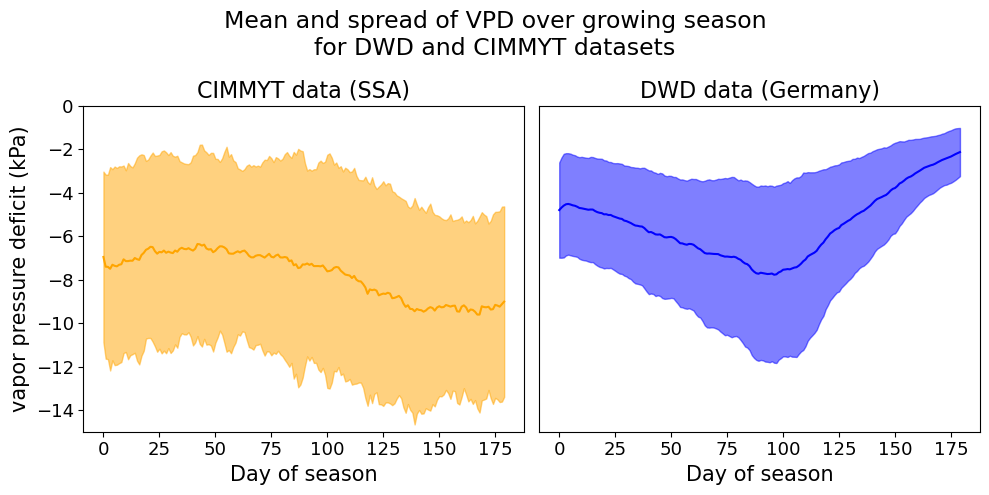

In [72]:
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
DE_mean = ds_inputs_DE[[f'vpd at day {n}' for n in range(180)]].mean().values
SSA_mean = ds_inputs_SSA[[f'vpd at day {n}' for n in range(180)]].mean().values
DE_var = ds_inputs_DE[[f'vpd at day {n}' for n in range(180)]].var().values
SSA_var = ds_inputs_SSA[[f'vpd at day {n}' for n in range(180)]].var().values

ax = axs[0]
ax.plot(range(180), SSA_mean, color = 'orange')
ax.fill_between(range(180), SSA_mean - np.sqrt(SSA_var), SSA_mean + np.sqrt(SSA_var), color = 'orange', alpha = 0.5)
ax.set_ylim((-15, 0))
ax.set_ylabel('vapor pressure deficit (kPa)', fontsize = 15)
ax.tick_params(which = 'both', labelsize = 13)
ax.set_xlabel('Day of season', fontsize = 15)
ax.set_title('CIMMYT data (SSA)', fontsize = 16)

ax = axs[1]
ax.plot(range(180), DE_mean, color = 'blue')
ax.fill_between(range(180), DE_mean - np.sqrt(DE_var), DE_mean + np.sqrt(DE_var), color = 'blue', alpha = 0.5)
ax.set_ylim((-15, 0))
ax.tick_params(which = 'both', labelsize = 13, labelleft = False, left = False)
ax.set_xlabel('Day of season', fontsize = 15)
ax.set_title('DWD data (Germany)', fontsize = 16)
#sns.histplot(ds_inputs_SSA[[f'vpd at day {n}' for n in range(180)]].values.flatten(), stat='density', bins = 50, ax=ax)
#sns.histplot(ds_inputs_DE[[f'vpd at day {n}' for n in range(180)]].values.flatten(), stat='density', bins = 50, ax=ax)

fig.suptitle('Mean and spread of VPD over growing season\nfor DWD and CIMMYT datasets', fontsize = 17)
fig.tight_layout()
fig.savefig('./../plots/vpd.png', bbox_inches = 'tight')


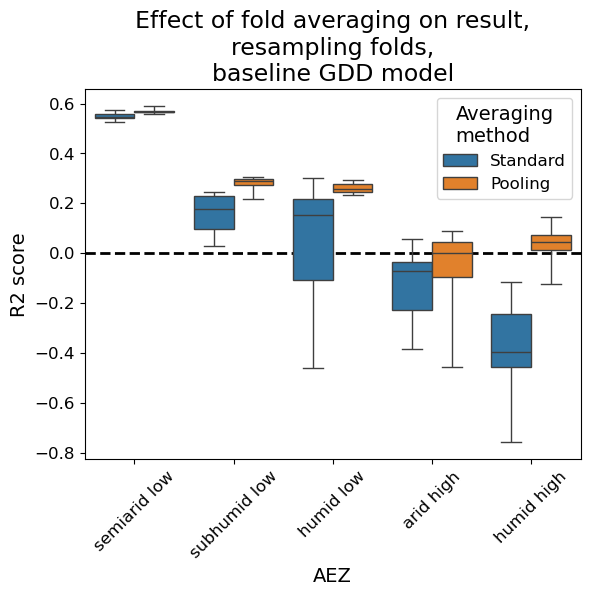

In [71]:
comp_scores_full = pd.read_csv('./comp_scores.csv')
comp_scores_full.AEZ = pd.Categorical(comp_scores_full.loc[:, 'AEZ'], categories = ['semiarid low', 'subhumid low', 'humid low', 'arid high', 'humid high'], ordered = True)#'WaveNet\nin domain KG', 'WaveNet TL', 
fig, ax = plt.subplots()
sns.boxplot(data = comp_scores_full, x= 'AEZ', y = 'Skill score', hue='Fold averaging', ax=ax, whis=(0, 100))
ax.axhline(0, color='k', linewidth = 2, linestyle = '--', zorder = 0)
ax.set_ylabel('R2 score', fontsize = 14)
ax.set_xlabel('AEZ', fontsize = 14)
ax.tick_params(which='both', labelsize = 12)
ax.tick_params('x', rotation = 45)
plt.legend(title = 'Averaging\nmethod', fontsize=12, title_fontsize=14)
ax.set_title('Effect of fold averaging on result,\nresampling folds,\nbaseline GDD model', fontsize = 17)
fig.savefig('./../plots/r2_split.png', bbox_inches = 'tight')